# Random Forests, Ensemble Learning, Bagging & Pasting

# Ensemble Learning

This notion - that multiple overfitting estimators can be combined to reduce the effect of this overfitting - is what underlies an **ensemble method**. 

## Bagging and Pasting

Voting classifiers with the same training algorithm for every predictor and train them on different random subsets of the training set. When the **sampling** is performed **with replacement**, this method is called **bagging** (or **Bootstrap Aggregating**). When **sampling** is performed **without replacement**, it is called **Pasting**.

In other words, both bagging and pasting allow training instances to be sampled several times across multiple predictors, but only bagging allows training instances to be sampled several times for the same predictor.

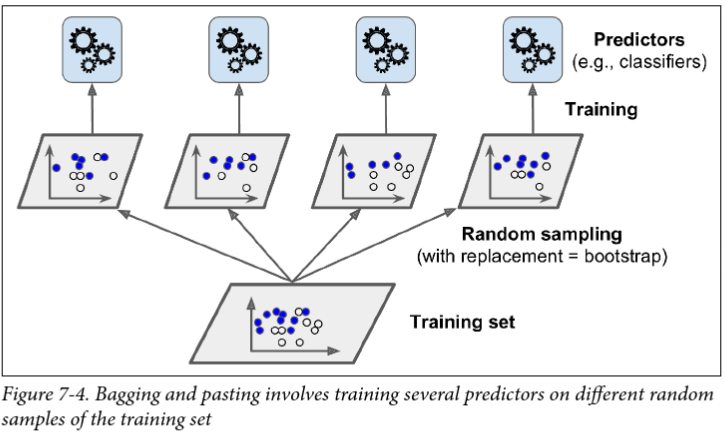

In [1]:
from IPython.display import Image
Image('figures/bagging.png', width=700)

# Source: Aurelien Geron. "Hands-On Machine Learning with Scikit-Learn, 
# Keras, and TensorFlow : Concepts, Tools, and Techniques to Build Intelligent Systems", O'Reilly Media, 2019.

Once all predictors are trained, the ensemble can make a prediction for a new instance by simply aggregating the predictions of all predictors. The aggregation function is typically the **statistical mode**, i.e., the most frequent prediction, just like a **hard voting classifier for classification**, or the **average for regression**. 

* Each individual predictor has a **higher bias** (i.e. it is **underfitting**) than if it were trained on the original training set, but aggregation reduces both bias and variance. 

* Generally, the net result is that the ensemble has a similar bias but a lower variance than a single predictor trained on the original training set.

Predictors can all be **trained in parallel**, via different CPU cores or even different servers. Similarly, predictions can be made in parallel. This is one of the reasons bagging and pasting are such popular methods: **they scale very well**.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.style.use('bmh')

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

In [3]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

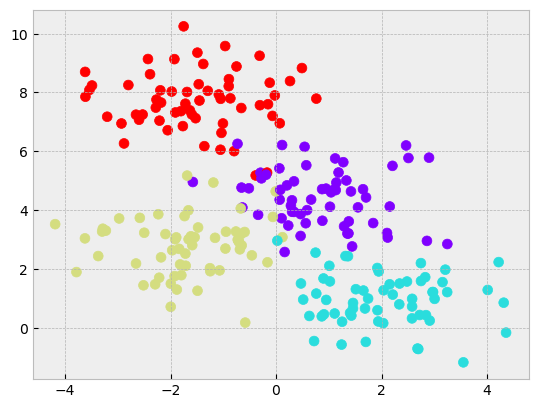

In [4]:
X, t = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

# Split data
X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    stratify=t,
                                                    test_size=0.2,
                                                    random_state=0)

# Visualize it
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_train, s=50, cmap='rainbow');

Training performance: 1.0
Test performance: 0.9


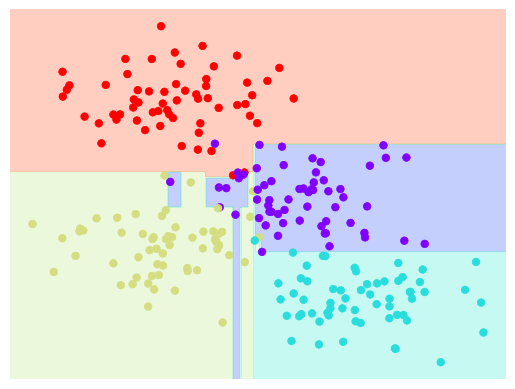

In [5]:
## EXAMPLE: DECISION TREE CLASSIFIER

# Setup pipeline
dec_tree = Pipeline([('scaler', MinMaxScaler()),
                    ('dec_tree', DecisionTreeClassifier(random_state=0))])
# Train pipeline
dec_tree.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(dec_tree, X_train, t_train)

# Predictions & Metric Scores
y_train1 = dec_tree.predict(X_train)
y_test1 = dec_tree.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train1))
print('Test performance:',
      accuracy_score(t_test, y_test1))

## Examples of Bagging

Training performance: 0.9791666666666666
Test performance: 0.9166666666666666


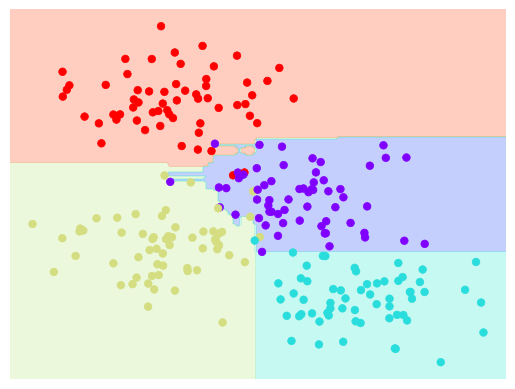

In [6]:
## EXAMPLE: BAGGING WITH DECISION TREES

# Setup pipeline
bag1 = Pipeline([('scaler', MinMaxScaler()),
                ('bagging', BaggingClassifier(DecisionTreeClassifier(max_depth=5,random_state=0),
                                              n_estimators=100,
                                             bootstrap=True,
                                             oob_score=True,
                                             max_samples=0.8, # resamples 80% of training samples using Bootstrap
                                             random_state=1))])
# Train pipeline
bag1.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(bag1, X_train, t_train)

# Predictions & Metric Scores
y_train1 = bag1.predict(X_train)
y_test1 = bag1.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train1))
print('Test performance:',
      accuracy_score(t_test, y_test1))

Training performance: 0.9458333333333333
Test performance: 0.9166666666666666


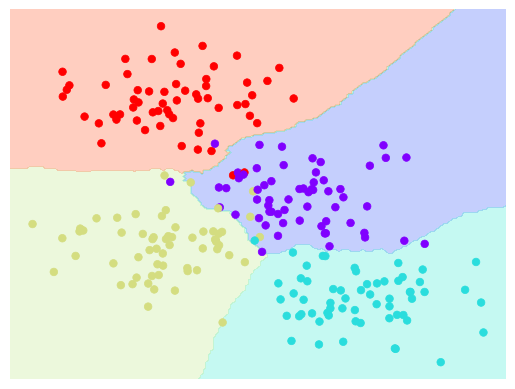

In [7]:
## EXAMPLE: BAGGING WITH K-NEAREST NEIGHBORS CLASSIFIER
from sklearn.neighbors import KNeighborsClassifier

# Setup pipeline
bag2 = Pipeline([('scaler', MinMaxScaler()),
                ('bagging', BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                                              n_estimators=100,
                                             bootstrap=True,
                                             oob_score=True,
                                             max_samples=0.8,
                                             random_state=1))])
# Train pipeline
bag2.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(bag2, X_train, t_train)

# Predictions & Metric Scores
y_train2 = bag2.predict(X_train)
y_test2 = bag2.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train2))
print('Test performance:',
      accuracy_score(t_test, y_test2))

In this example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points. In practice, decision trees are more effectively randomized by injecting some stochasticity in how the splits are chosen: this way all the data contributes to the fit each time, but the results of the fit still have the desired randomness. For example, when determining which feature to split on, the randomized tree might select from among the top several features. You can read more technical details about these randomization strategies in the [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/ensemble.html#forest) and references within.

### Example of Pasting

Training performance: 0.925
Test performance: 0.9


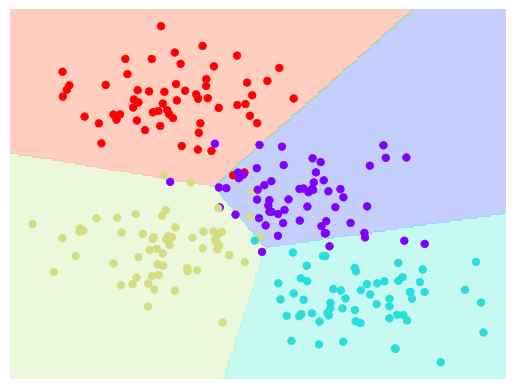

In [8]:
## EXAMPLE: PASTING WITH LOGISTIC REGRESSION

# Setup pipeline
pasting_clf = Pipeline([('scaler', MinMaxScaler()),
                ('bagging', BaggingClassifier(LogisticRegression(),
                                              n_estimators=100,
                                             bootstrap=False, # you are still resampling but WITHOUT replacement
                                             max_samples=0.8,
                                      
                                             random_state=1))])
# Train pipeline
pasting_clf.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(pasting_clf, X_train, t_train)

# Predictions & Metric Scores
y_train3 = pasting_clf.predict(X_train)
y_test3 = pasting_clf.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train3))
print('Test performance:',
      accuracy_score(t_test, y_test3))

---

## Out-of-Bag Evaluation

With bagging, some instances may be sampled several times for any given predictor, while others may not be sampled at all. By default a ```BaggingClassifier``` samples $m$ training instances with replacement (```bootstrap=True```), where $m$ is the size of the training set. This means that only about 63% of the training instances are sampled on average for each predictor. The remaining 37% of the training instances that are not sampled are called **out-of-bag (oob) instances**. Note that they are not the same 37% for all predictors. 

A bagging ensemble can be evaluated using oob instances, without the need for a separate validation set: indeed, if there are enough estimators, then each instance in the training set will likely be an oob instance of several estimators, so these estimators can be used to make a fair ensemble prediction for that instance. Once you have a prediction for each instance, you can compute the ensemble's prediction accuracy (or any other metric).

In [9]:
bag1

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('bagging',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                                    random_state=0),
                                   max_samples=0.8, n_estimators=100,
                                   oob_score=True, random_state=1))])

In [10]:
print('Out of bag Score:', bag1.named_steps.bagging.oob_score_)
print('Test Set Score: ', accuracy_score(t_test, y_test1))

Out of bag Score: 0.9291666666666667
Test Set Score:  0.9166666666666666


In [11]:
bag2

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('bagging',
                 BaggingClassifier(estimator=KNeighborsClassifier(),
                                   max_samples=0.8, n_estimators=100,
                                   oob_score=True, random_state=1))])

In [12]:
print('Out of bag Score:', bag2.named_steps['bagging'].oob_score_)
print('Test Set Score: ', accuracy_score(t_test, y_test2))

Out of bag Score: 0.9333333333333333
Test Set Score:  0.9166666666666666


The oob decision function for each training instance is also available through the ```oob_decision_function_``` variable. In this case (since the base estimator has a ```predict_proba()``` method), the decision function returns the class probabilities for each training instance. For example, the oob evaluation estimates that the fourth training instance has a 79.07% probability of belonging to class 4 (and 20.93% of belonging to class 1, 0% to class 2 and 0% to class 3):

In [13]:
bag1.named_steps.bagging.oob_decision_function_

# Matrix of shape N-by-C, N is the number of samples and C is the number of classes

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.76397516e-04, 0.00000000e+00, 9.99223602e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [2.09302326e-01, 0.00000000e+00, 0.00000000e+00, 7.90697674e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00],
       [8.89937107e-01, 5.66037736e-02, 5.34591195e-02, 0.00000000e+00],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [2.22222222e-02, 9.77777778e-01, 0.00000000e+00, 0.00000000e+00],
       [9.99074074e-01, 0.00000000e+00, 4.62962963e-04, 4.62962963e-04],
       [9.99479167e-01, 0.00000000e+00, 0.00000000e

---

## Random Patches and Random Subspaces

The ```BaggingClassifier``` class supports sampling the features as well. Sampling is controlled by two hyperparameters: ```max_features``` and ```bootstrap_features```. They work the same way as ```max_samples``` and ```bootstrap```, but for feature sampling instead of instance sampling. Thus, each predictor will be trained on a **random subset of the input features**. This technique is **particularly useful when you are dealing with high-dimensional inputs** (such as images). 

* Sampling both training instances and features is called the **Random Patches method**. 

* Keeping all training instances (by setting ```bootstrap=False``` and ```max_samples=1.0```) but sampling features (by setting ```bootstrap_features=True``` and/or ```max_features``` to a value equal or smaller than 1.0) is called the **Random Subspaces method**. Sampling features results in even more predictor diversity, trading a bit **more bias for a lower variance**.

## Example of Random Pacthes

Training performance: 0.9708333333333333
Test performance: 0.8833333333333333


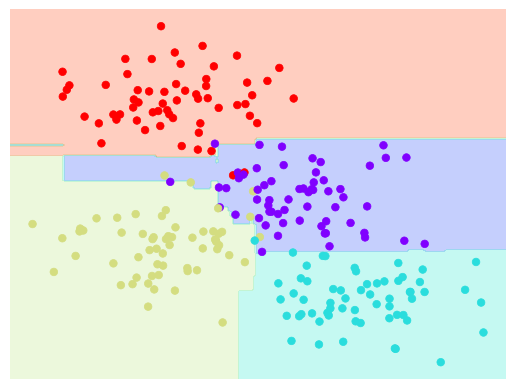

In [14]:
## EXAMPLE: RANDOM PATCHES

# Setup pipeline
rnd_patch = Pipeline([('scaler', MinMaxScaler()),
                ('bagging', BaggingClassifier(DecisionTreeClassifier(max_depth=3,random_state=0),
                                             n_estimators=60,
                                             bootstrap=True,
                                             max_samples=0.8,
                                             bootstrap_features=True,
                                             max_features=1.0,
                                             random_state=0))])
# Train pipeline
rnd_patch.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(rnd_patch, X_train, t_train)

# Predictions & Metric Scores
y_train3 = rnd_patch.predict(X_train)
y_test3 = rnd_patch.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train3))
print('Test performance:',
      accuracy_score(t_test, y_test3))

### Example of Random Subspaces

Training performance: 0.9708333333333333
Test performance: 0.8833333333333333


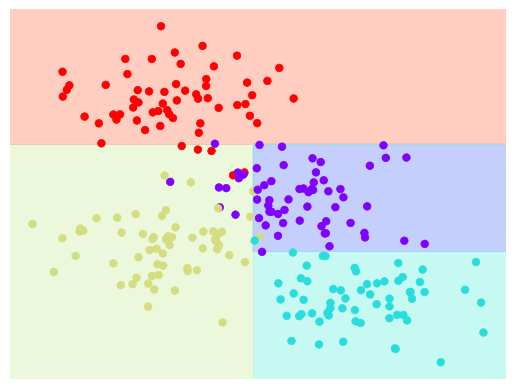

In [15]:
## EXAMPLE: RANDOM SUBSPACES

# Setup pipeline
rnd_subspace = Pipeline([('scaler', MinMaxScaler()),
                ('bagging', BaggingClassifier(DecisionTreeClassifier(max_depth=2,random_state=0),
                                             n_estimators=100,
                                             bootstrap=False, # Resampling WITHOUT replacement
                                             max_samples=1.0,
                                             bootstrap_features=True,
                                             max_features=1.0,
                                             random_state=0))])
# Train pipeline
rnd_subspace.fit(X_train, t_train)

# Visualize decision surface
visualize_classifier(rnd_subspace, X_train, t_train)

# Predictions & Metric Scores
y_train4 = rnd_patch.predict(X_train)
y_test4 = rnd_patch.predict(X_test)
print('Training performance:',
      accuracy_score(t_train, y_train4))
print('Test performance:',
      accuracy_score(t_test, y_test4))

---

# Random Forests

An example of bagging is **random forests**. A random forest is the collection of the same learning algorithm (decision trees) trained on Bootstrap samples of the training data.

In Scikit-Learn, such an optimized ensemble of randomized decision trees is implemented in the ```RandomForestClassifier``` estimator, which takes care of all the randomization automatically. All you need to do is select a number of estimators, and it will very quickly (in parallel, if desired) fit the ensemble of trees.

## Hyperparameters

With a few exceptions, a ```RandomForestClassifier``` has all the hyperparameters of a ```DecisionTreeClassifier``` (to control how trees are grown), plus all the hyperparameters of a ```BaggingClassifier``` to control the ensemble itself.

The Random Forest algorithm introduces extra randomness when growing trees; instead of searching for the very best feature when splitting a node, it **searches for the best feature among a random subset of features**. The algorithm results in greater tree diversity, which (again) trades a higher bias for a lower variance generally yielding an overall better model. The following is equivalent to the previous ```RandomForestClassifier```:

In [16]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier?

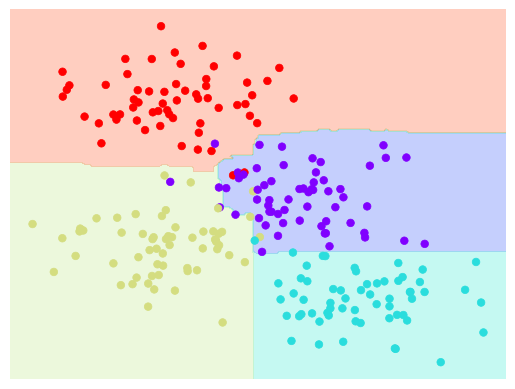

In [17]:
model = RandomForestClassifier(n_estimators=100,
                               bootstrap=True,
                               oob_score=True,
                               max_samples=0.8,
                               random_state=1,
                              max_depth=3,
                              min_samples_split=5)

visualize_classifier(model, X_train, t_train);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

## Extremely Randomized Trees (or Extra-Trees)

When you are growing a tree in a Random Forest, at each node only a random subset of the features is considered for splitting (as discussed earlier). It is possible to make trees even more random by also using random thresholds for each feature rather than searching for the best possible thresholds (like regular Decision Trees do). 

A forest of such extremely random trees is called an **Extremely Randomized Trees ensemble** (or **Extra-Trees** for short). Once again, this technique trades more bias for a lower variance. It also makes Extra-Trees much faster to train than regular Random Forests, because finding the best possible threshold for each feature at every node is one of the most time-consuming tasks of growing a tree. 

You can create an Extra-Trees classifier using Scikit-Learn’s ```ExtraTreesClassifier``` class. Its API is identical to the ```RandomForestClassifier``` class. Similarly, the ```ExtraTreesRegressor``` class has the same API as the ```RandomForestRegressor``` class.

In [18]:
from sklearn.ensemble import ExtraTreesClassifier

ExtraTreesClassifier?

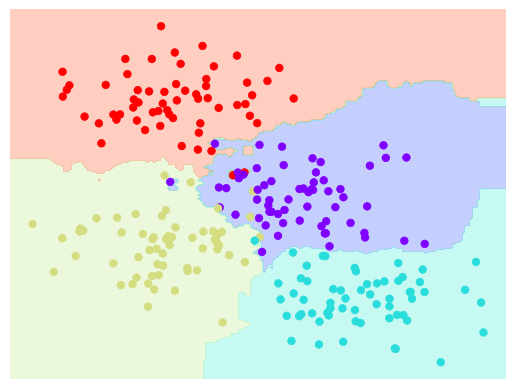

In [19]:
model2 = ExtraTreesClassifier(n_estimators=100,
                               bootstrap=True,
                               oob_score=True,
                               max_samples=0.8,
                               random_state=1)

visualize_classifier(model2, X_train, t_train);

## Feature Importance

Yet another great quality of Random Forests is that they make it easy to measure the relative importance of each feature. Scikit-Learn measures **a feature’s importance by looking at how much the tree nodes that use that feature reduce impurity on average** (across all trees in the forest). More precisely, it is a **weighted average**, where each node’s weight is equal to the number of training samples that are associated with it.

Scikit-Learn computes this score automatically for each feature after training, then it scales the results so that the sum of all importances is equal to 1. You can access the result using the ```feature_importances_``` variable.

In [20]:
model

RandomForestClassifier(max_depth=3, max_samples=0.8, min_samples_split=5,
                       oob_score=True, random_state=1)

In [21]:
model.feature_importances_

array([0.36244788, 0.63755212])

Consider the Iris dataset:

In [22]:
# Load Iris Dataset ( 4 features)
from sklearn.datasets import load_iris
iris = load_iris()

# Setting up pipeline
rnf_clf = Pipeline([('scaler', MinMaxScaler()),
                    ('rnf_clf', RandomForestClassifier(n_estimators=500))])

# Train pipeline
rnf_clf.fit(iris["data"], iris["target"])

# View feature importances
for name, score in zip(iris["feature_names"], 
                       rnf_clf.named_steps['rnf_clf'].feature_importances_): 
    print(name, score)

sepal length (cm) 0.09948572985900493
sepal width (cm) 0.02194323192541615
petal length (cm) 0.4459714851236513
petal width (cm) 0.4325995530919275


Consider the MNIST dataset:

In [23]:
from sklearn.datasets import fetch_openml 
# image dataset, 28x28 grayscale, 784 dimensions
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, t = mnist.data, mnist.target
t = t.astype(np.uint8)

# Partition into training and test sebytes
X_train, t_train, = X[:10000], t[:10000] #fetch a small sample size for training for demo purposes

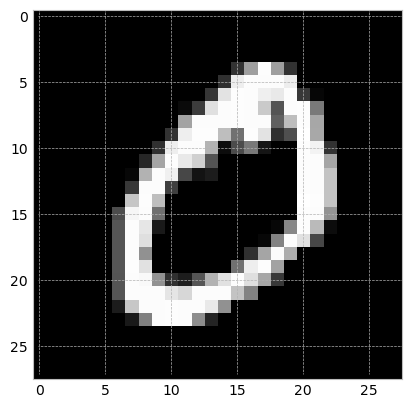

In [24]:
plt.imshow(X[1,:].reshape(28,28), cmap='gray');

In [25]:
# Setting up pipeline

model = Pipeline([('scaler', MinMaxScaler()),
                 ('rnf_clf', RandomForestClassifier(n_estimators=500))])
model.fit(X_train, t_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('rnf_clf', RandomForestClassifier(n_estimators=500))])

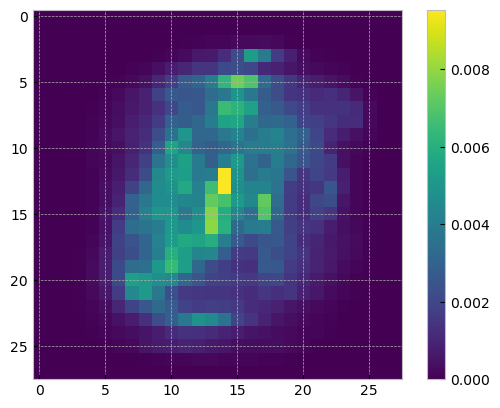

In [26]:
plt.imshow(model.named_steps.rnf_clf.feature_importances_.reshape(28,28))
plt.colorbar();

In [27]:
mask = 1*(model.named_steps.rnf_clf.feature_importances_>0.002)

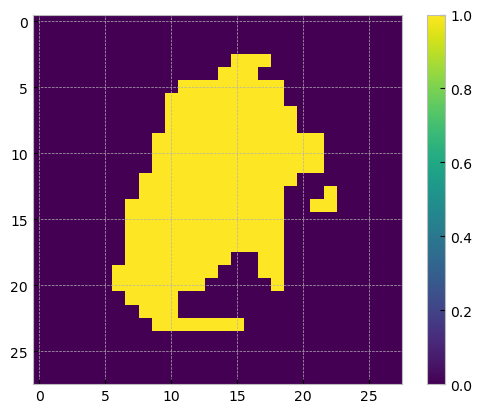

In [28]:
plt.imshow(mask.reshape(28,28))
plt.colorbar();

---

## Summary of Random Forests

Random forest is a type of *ensemble estimators*. Random forests are a powerful method with several **advantages**:

* Both training and prediction are very fast, because of the simplicity of the underlying decision trees. In addition, both tasks can be straightforwardly parallelized, because the individual trees are entirely independent entities.

* The multiple trees allow for a probabilistic classification: a majority vote among estimators gives an estimate of the probability (accessed in Scikit-Learn with the ```predict_proba()``` method).

* The non-parametric model is extremely flexible, and can thus perform well on tasks that are underfit by other estimators.

A primary **disadvantage** of random forests is that the results are not easily interpretable: that is, if you would like to draw conclusions about the meaning of the classification model, random forests may not be the best choice.

---
---

# Boosting

**Boosting** (or **Hypothesis Boosting**) refers to any Ensemble method that can combine several weak learners into a strong learner. The general idea of most boosting methods is to train predictors sequentially, each trying to correct its predecessor. There are many boosting methods available, but by far the most popular are **AdaBoost** (short for **Adaptive Boosting**) and **Gradient Boosting**.

## AdaBoost (or Adaptive Boosting)

One way for a new predictor to correct its predecessor is to pay a bit more attention to the training samples that the predecessor underfitted. This results in new predictors focusing more and more on the "difficult samples". This is the technique used by AdaBoost. 

For example, when training an AdaBoost classifier, the algorithm first trains a base classifier (such as a Decision Tree) and uses it to make predictions on the training set. The algorithm then increases the relative weight of misclassified training instances. Then it trains a second classifier, using the updated weights, and again makes predictions on the training set, updates the instance weights, and so on.

The first classifier gets many instances wrong, so their weights get boosted. The second classifier therefore does a better job on these instances, and so on. This sequential learning technique has some similarities with Gradient Descent, except that instead of tweaking a single predictor's parameters to minimize a cost function, AdaBoost adds predictors to the ensemble, gradually making it better.

### Weight Assignment

Each sample weight $w^{(i)}$ is initially set to $1/N$ (where $N$ is the number of samples). A first predictor is trained, and its weighted error rate $r_1$ is computed on the training set.

In general, the **weighted error rate of the $j$-th predictor** is:

\begin{align*}
r_j = \frac{\sum\limits_{\substack{i=1 \\ \hat{y}_j^{(i)}\neq y^{(i)}}}^N w^{(i)}}{\sum_{i=1}^N w^{(i)}}
\end{align*}

where $\hat{y}_j$ is the $j$-th predictor's prediction for the $i$-th sample. The numerator sums all samples' weights for which the prediction is incorrect. The denominator sums all samples' weights.

The **predictor's weight** $\alpha_j$ is then computed with

\begin{align*}
\alpha_j = \eta \ln\frac{1-r_j}{r_j}
\end{align*}

where $\eta$ is the learning rate hyperparameter (defaults to 1). 

In [29]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

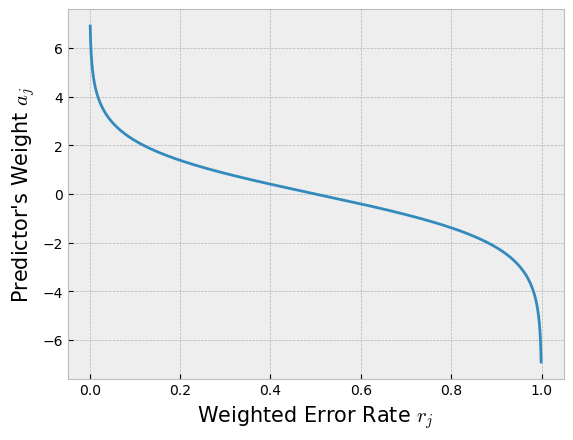

In [30]:
eta = 1
r = np.linspace(0.001,0.999,10_000)
a = eta*np.log((1-r)/r)

plt.plot(r,a)
plt.xlabel('Weighted Error Rate $r_j$',size=15)
plt.ylabel("Predictor's Weight $a_j$", size=15);

The more accurate the predictor is, the higher its weight $\alpha_j$ will be. If it is just guessing randomly, then its weight will be close to zero. However, if it is most often wrong (i.e., less accurate than random guessing), then its weight will be negative.

Next, the AdaBoost algorithm updates the instance weights using the update equation:

\begin{align*}
w^{(i)} \longleftarrow \begin{cases} w^{(i)} & \text{if } \hat{y}_j^{(i)}=y^{(i)} \\ w^{(i)}\exp(\alpha_j) & \text{if } \hat{y}_j^{(i)}\neq y^{(i)} \end{cases}\text{, }\forall i=1,2,\dots, N
\end{align*}

which boosts the weights of the misclassified instances.

Then all the instance weights are normalized (i.e., divided by $\sum_{i=1}^N w^{(i)}$).

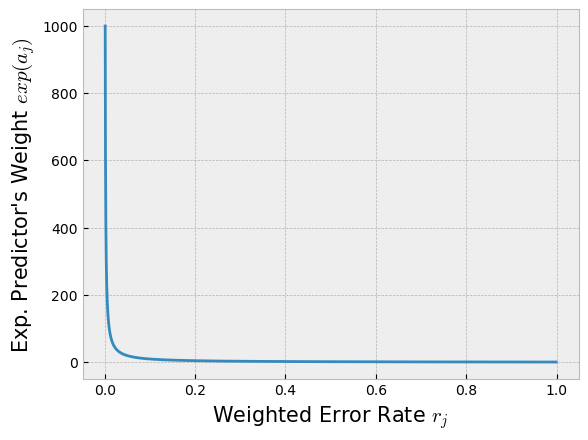

In [31]:
plt.plot(r,np.exp(a))
plt.xlabel('Weighted Error Rate $r_j$',size=15)
plt.ylabel("Exp. Predictor's Weight $exp(a_j)$", size=15);

Finally, a new predictor is trained using the updated weights, and the whole process is repeated (the new predictor's weight is computed, the instance weights are updated, then another predictor is trained, and so on). 

The **convergence criteria** includes: reaching the desired number of predictors or zero errors.

To make predictions, AdaBoost simply computes the predictions of all the predictors and weighs them using the predictor weights $\alpha_j$. The predicted class is the one that receives the majority of weighted votes:

\begin{align*}
\hat{y}(x) = \arg_k\max \sum\limits_{\substack{j=1 \\ \hat{y}_j(x)=k}}^M \alpha_j
\end{align*}

where $M$ is the number of predictors, and $k$ is the class label.

In [32]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

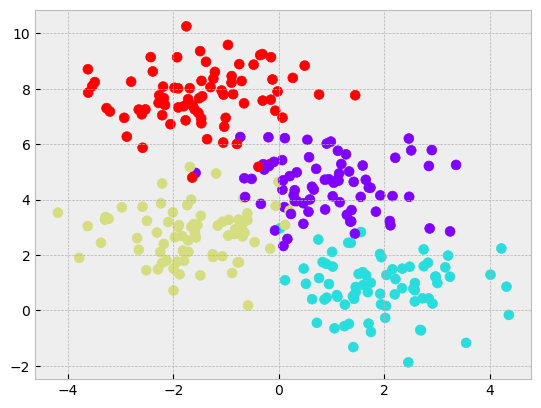

In [33]:
X, t = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)

plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='rainbow');

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    stratify=t,
                                                   test_size=0.2)

# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.ensemble import AdaBoostClassifier

AdaBoostClassifier?

In [35]:
from sklearn.ensemble import AdaBoostRegressor

AdaBoostRegressor?

```Scikit-Learn``` uses a multi-class version of AdaBoost called **SAMME** (which stands for **Stagewise Additive Modeling using a Multiclass Exponential** loss function). When there are just two classes, SAMME is equivalent to AdaBoost.

In [36]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=4), 
    n_estimators=2,
    learning_rate=1,
    algorithm='SAMME') 

ada_clf.fit(X_train, t_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=4),
                   learning_rate=1, n_estimators=2)

Train Accuracy: 0.9333333333333333
Test Accuracy: 0.9166666666666666


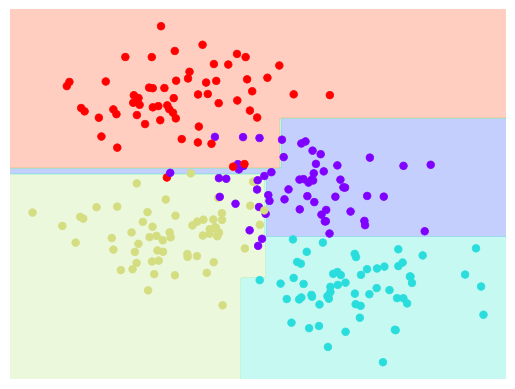

In [37]:
visualize_classifier(ada_clf, X_train, t_train)

y_train = ada_clf.predict(X_train)
y_test = ada_clf.predict(X_test)
print('Train Accuracy:', 
      accuracy_score(t_train, y_train))
print('Test Accuracy:', 
      accuracy_score(t_test, y_test))

If your AdaBoost ensemble is overfitting the training set, you can try reducing the number of estimators or more strongly regularizing the base estimator.

---

---

# Gradient Boosting

Another very popular boosting algorithm is **Gradient Boosting**. Just like AdaBoost, Gradient Boosting works by sequentially adding predictors to an ensemble, each one correcting its predecessor. However, instead of tweaking the instance weights at every iteration like AdaBoost does, this method tries to **fit the new predictor to the residual errors made by the previous predictor**. 

Let's go through a simple regression example, using Decision Trees as the base predictors (of course, Gradient Boosting also works great with regression tasks). This is called Gradient Tree Boosting, or **Gradient Boosted Regression Trees (or GBRT)**. First, let's fit a ```DecisionTreeRegressor``` to the training set (for example, a noisy quadratic training set):

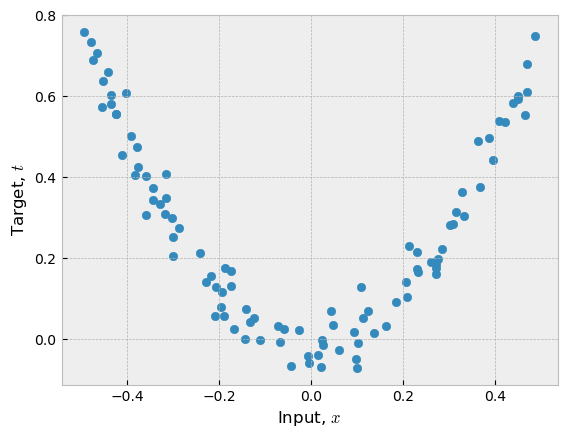

In [38]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
t = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

plt.scatter(X, t)
plt.xlabel('Input, $x$'); plt.ylabel('Target, $t$');

In [39]:
from sklearn.tree import DecisionTreeRegressor 

tree_reg1 = DecisionTreeRegressor(max_depth=2) 
tree_reg1.fit(X, t)

DecisionTreeRegressor(max_depth=2)

Next, we'll train a second ```DecisionTreeRegressor``` predictor on the residual errors made by the first predictor:

In [40]:
# The new target for the next predictor is the residual error from the previous predictor

t2 = t - tree_reg1.predict(X) 

tree_reg2 = DecisionTreeRegressor(max_depth=2) 
tree_reg2.fit(X, t2) 

DecisionTreeRegressor(max_depth=2)

Then we train a third regressor on the residual errors made by the second predictor:

In [41]:
t3 = t2 - tree_reg2.predict(X) 

tree_reg3 = DecisionTreeRegressor(max_depth=2) 
tree_reg3.fit(X, t3)

DecisionTreeRegressor(max_depth=2)

Now we have an ensemble containing three trees. It can make predictions on a new instance simply by adding up the predictions of all the trees: 

In [42]:
X_new = np.array([[-0.3]])

X_new

array([[-0.3]])

In [43]:
[tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3)]

[array([0.12356613]), array([0.15983802]), array([0.00704347])]

In [44]:
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

y_pred

array([0.29044761])

The plot below represents the predictions of these three trees in the left column, and the ensemble's predictions in the right column. 

* In the first row, the ensemble has just one tree, so its predictions are exactly the same as the first tree's predictions. 

* In the second row, a new tree is trained on the residual errors of the first tree. On the right you can see that the ensemble's predictions are equal to the sum of the predictions of the first two trees. 
* Similarly, in the third row another tree is trained on the residual errors of the second tree. 

You can see that the ensemble's predictions gradually get better as trees are added to the ensemble.

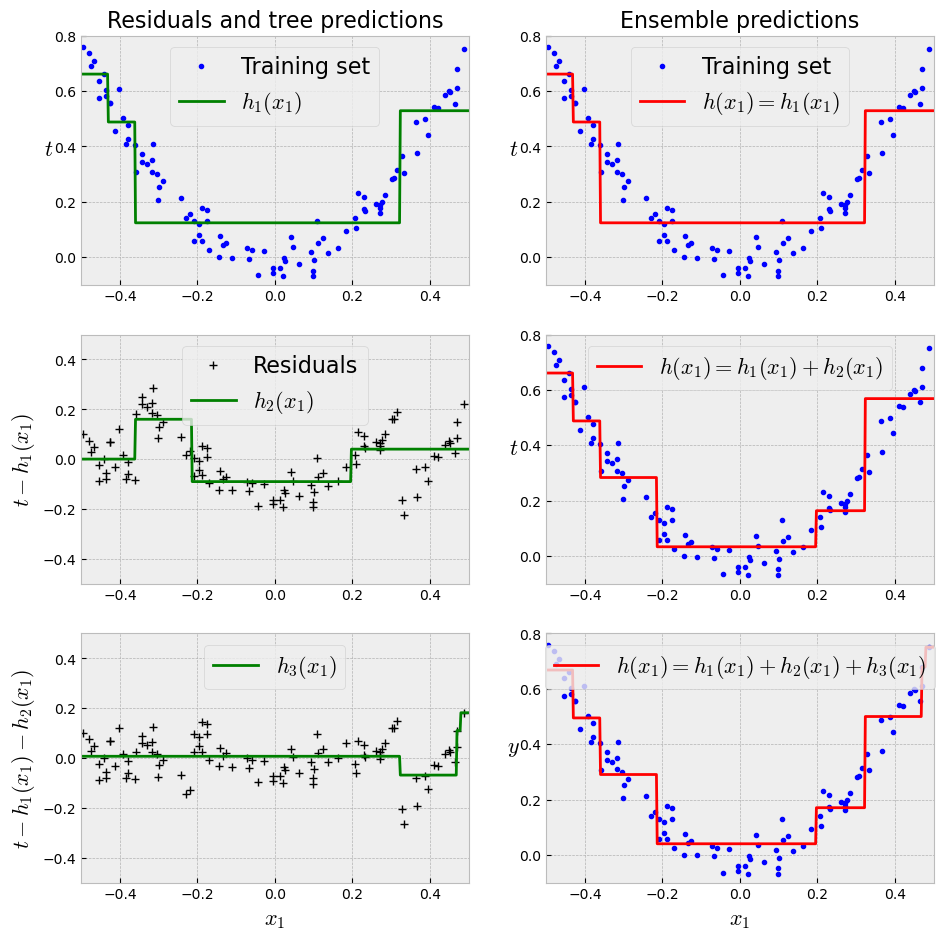

In [45]:
def plot_predictions(regressors, X, t, axes, label=None, style="r-", data_style="b.", data_label=None):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], t, data_style, label=data_label)
    plt.plot(x1, y_pred, style, linewidth=2, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)
    plt.axis(axes)
    
plt.figure(figsize=(11,11))
plt.subplot(321)
plot_predictions([tree_reg1], X, t, axes=[-0.5, 0.5, -0.1, 0.8], label="$h_1(x_1)$", style="g-", data_label="Training set")
plt.ylabel("$t$", fontsize=16, rotation=0)
plt.title("Residuals and tree predictions", fontsize=16)

plt.subplot(322)
plot_predictions([tree_reg1], X, t, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1)$", data_label="Training set")
plt.ylabel("$t$", fontsize=16, rotation=0)
plt.title("Ensemble predictions", fontsize=16)

plt.subplot(323)
plot_predictions([tree_reg2], X, t2, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_2(x_1)$", style="g-", data_style="k+", data_label="Residuals")
plt.ylabel("$t - h_1(x_1)$", fontsize=16)

plt.subplot(324)
plot_predictions([tree_reg1, tree_reg2], X, t, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1)$")
plt.ylabel("$t$", fontsize=16, rotation=0)

plt.subplot(325)
plot_predictions([tree_reg3], X, t3, axes=[-0.5, 0.5, -0.5, 0.5], label="$h_3(x_1)$", style="g-", data_style="k+")
plt.ylabel("$t - h_1(x_1) - h_2(x_1)$", fontsize=16)
plt.xlabel("$x_1$", fontsize=16)

plt.subplot(326)
plot_predictions([tree_reg1, tree_reg2, tree_reg3], X, t, axes=[-0.5, 0.5, -0.1, 0.8], label="$h(x_1) = h_1(x_1) + h_2(x_1) + h_3(x_1)$")
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0);

A simpler way to train GBRT ensembles is to use ```Scikit-Learn```'s ```GradientBoostingRegressor``` class. Much like the ```RandomForestRegressor``` class, it has hyperparameters to control the growth of Decision Trees (e.g., ```max_depth```, ```min_samples_leaf```), as well as hyperparameters to control the ensemble training, such as the number of trees (```n_estimators```). The following code creates the same ensemble as the previous one:

In [46]:
from sklearn.ensemble import GradientBoostingRegressor 

GradientBoostingRegressor?

In [47]:
gbrt = GradientBoostingRegressor(max_depth=2, 
                                 n_estimators=3, 
                                 learning_rate=0.1) 

gbrt.fit(X, t)

GradientBoostingRegressor(max_depth=2, n_estimators=3)

The ```learning_rate``` hyperparameter scales the contribution of each tree. 

* If you set it to a low value, such as 0.1, you will need more trees in the ensemble to fit the training set, but the predictions will usually generalize better. 

This is a regularization technique called **shrinkage**.

In [48]:
gbrt_slow = GradientBoostingRegressor(max_depth=2, 
                                      n_estimators=200, 
                                      learning_rate=0.1, 
                                      random_state=42)

gbrt_slow.fit(X, t)

GradientBoostingRegressor(max_depth=2, n_estimators=200, random_state=42)

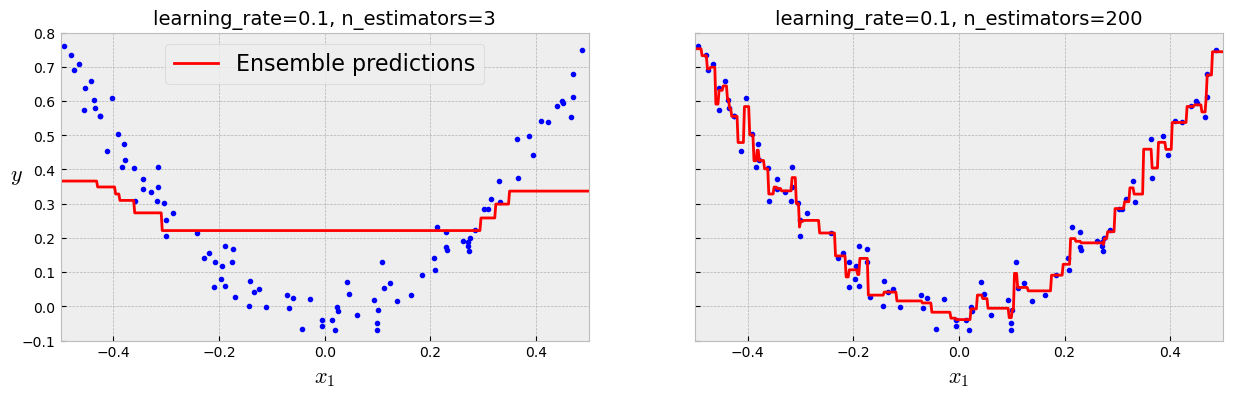

In [49]:
fix, axes = plt.subplots(ncols=2, figsize=(15,4), sharey=True)

plt.sca(axes[0])
plot_predictions([gbrt], X, t, axes=[-0.5, 0.5, -0.1, 0.8], label="Ensemble predictions")
plt.title("learning_rate={}, n_estimators={}".format(gbrt.learning_rate, gbrt.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.sca(axes[1])
plot_predictions([gbrt_slow], X, t, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("learning_rate={}, n_estimators={}".format(gbrt_slow.learning_rate, gbrt_slow.n_estimators), fontsize=14)
plt.xlabel("$x_1$", fontsize=16);

* The plot one on the left does not have enough trees to fit the training set (large ```learning_rate```) 

* The one on the right has too many trees and overfits the training set (small ```learning_rate```)

In order to find the optimal number of trees, you can use **early stopping**. 

A simple way to implement this is to use the ```staged_predict()``` method: it returns an iterator over the predictions made by the ensemble at each stage of training (with one tree, two trees, etc.). 

The following code trains a GBRT ensemble with 120 trees, then measures the validation error at each stage of training to find the optimal number of trees, and finally trains another GBRT ensemble using the optimal number of trees:

In [50]:
## Gradient Boosting with Early Stopping

from sklearn.metrics import mean_squared_error

X_train, X_val, t_train, t_val = train_test_split(X, t, random_state=49)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)
gbrt.fit(X_train, t_train)

GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)

In [51]:
errors = [mean_squared_error(t_val, y_pred) 
          for y_pred in gbrt.staged_predict(X_val)]
# errors

In [52]:
bst_n_estimators = np.argmin(errors) + 1
bst_n_estimators

np.int64(56)

In [53]:
gbrt_best = GradientBoostingRegressor(max_depth=2, 
                                      n_estimators=bst_n_estimators, 
                                      random_state=42)

gbrt_best.fit(X_train, t_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(56),
                          random_state=42)

The validation errors are represented on the left, and the best model's predictions are represented on the right.

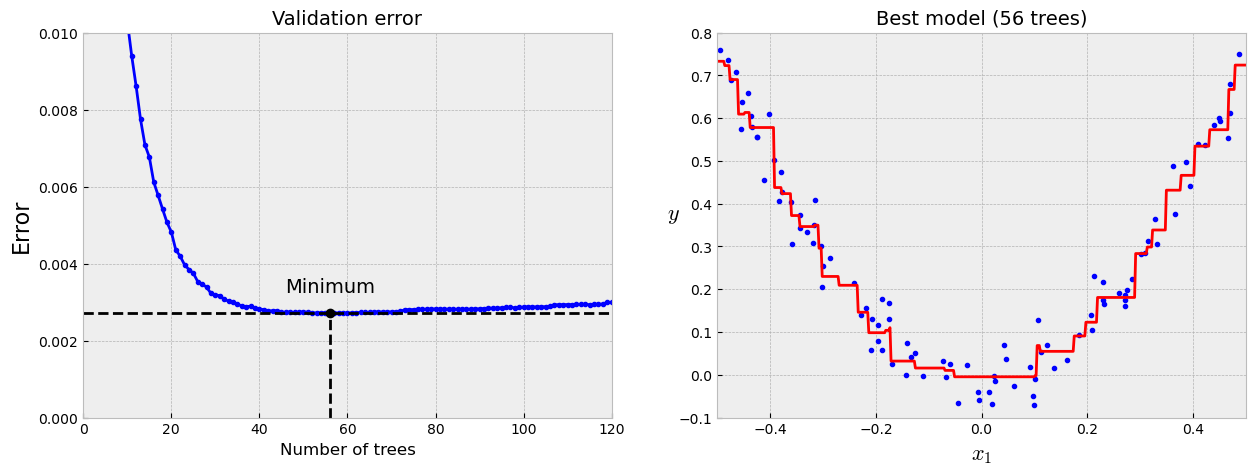

In [54]:
min_error = np.min(errors)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.plot(np.arange(1, len(errors) + 1), errors, "b.-")
plt.plot([bst_n_estimators, bst_n_estimators], [0, min_error], "k--")
plt.plot([0, 120], [min_error, min_error], "k--")
plt.plot(bst_n_estimators, min_error, "ko")
plt.text(bst_n_estimators, min_error*1.2, "Minimum", ha="center", fontsize=14)
plt.axis([0, 120, 0, 0.01])
plt.xlabel("Number of trees")
plt.ylabel("Error", fontsize=16)
plt.title("Validation error", fontsize=14)

plt.subplot(122)
plot_predictions([gbrt_best], X, t, axes=[-0.5, 0.5, -0.1, 0.8])
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)
plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16);

Alternatively, you can tweak the hyperparameters ```validation_fraction``` or ```n_iter_no_change```:

In [55]:
gbrt = GradientBoostingRegressor(max_depth=2, 
                                      n_estimators=200,
                                      validation_fraction=0.1,
                                      n_iter_no_change=5, # patience
                                      random_state=42)

gbrt.fit(X_train, t_train)

GradientBoostingRegressor(max_depth=2, n_estimators=200, n_iter_no_change=5,
                          random_state=42)

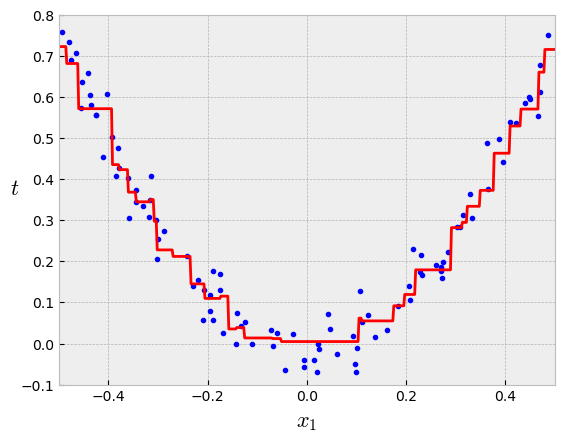

In [56]:
plot_predictions([gbrt], X, t, axes=[-0.5, 0.5, -0.1, 0.8])
plt.ylabel("$t$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16);

### Stochastic Gradient Boosting

The ```GradientBoostingRegressor``` class also supports a ```subsample``` hyperparameter, which specifies the fraction of training instances to be used for training each tree. 

* For example, if ```subsample=0.25```, then each tree is trained on 25% of the training instances, selected randomly. As you can probably guess by now, this technique trades a higher bias for a lower variance. It also speeds up training considerably.

This is called **Stochastic Gradient Boosting**.

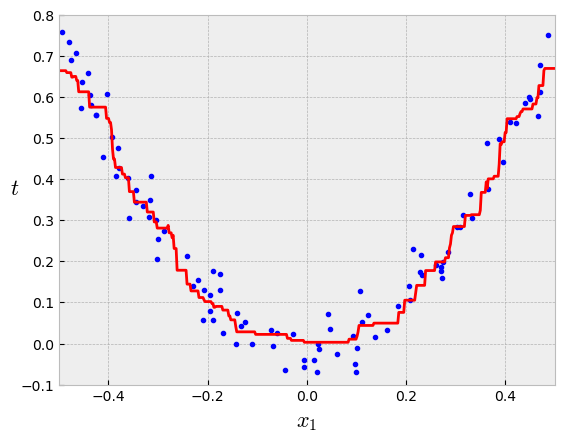

In [57]:
gbrt = GradientBoostingRegressor(max_depth=2, 
                                 n_estimators=200,
                                 validation_fraction=0.1,
                                 n_iter_no_change=5,
                                 subsample=0.25,
                                 random_state=42)

gbrt.fit(X_train, t_train)

plot_predictions([gbrt], X, t, axes=[-0.5, 0.5, -0.1, 0.8])
plt.ylabel("$t$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16);

---